In [6]:
import os
import optuna
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorboard.backend.event_processing import event_accumulator
from tbparse import SummaryReader

plt.rcParams.update({
    "text.usetex": False,  # Use LaTeX for all text (if available)
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": True
})

In [7]:
storage='sqlite:///'+os.path.join(os.path.dirname(os.path.dirname(os.path.abspath(""))),"optuna_studies","optuna_study.db")

In [8]:
summaries = optuna.study.get_all_study_summaries(storage=storage)
for summary in summaries:
    print(f"Study name: {summary.study_name} | Trials: {summary.n_trials}")

Study name: Reward Shaping Study | Trials: 30


In [9]:
study = optuna.load_study(study_name=summary.study_name, storage=storage)

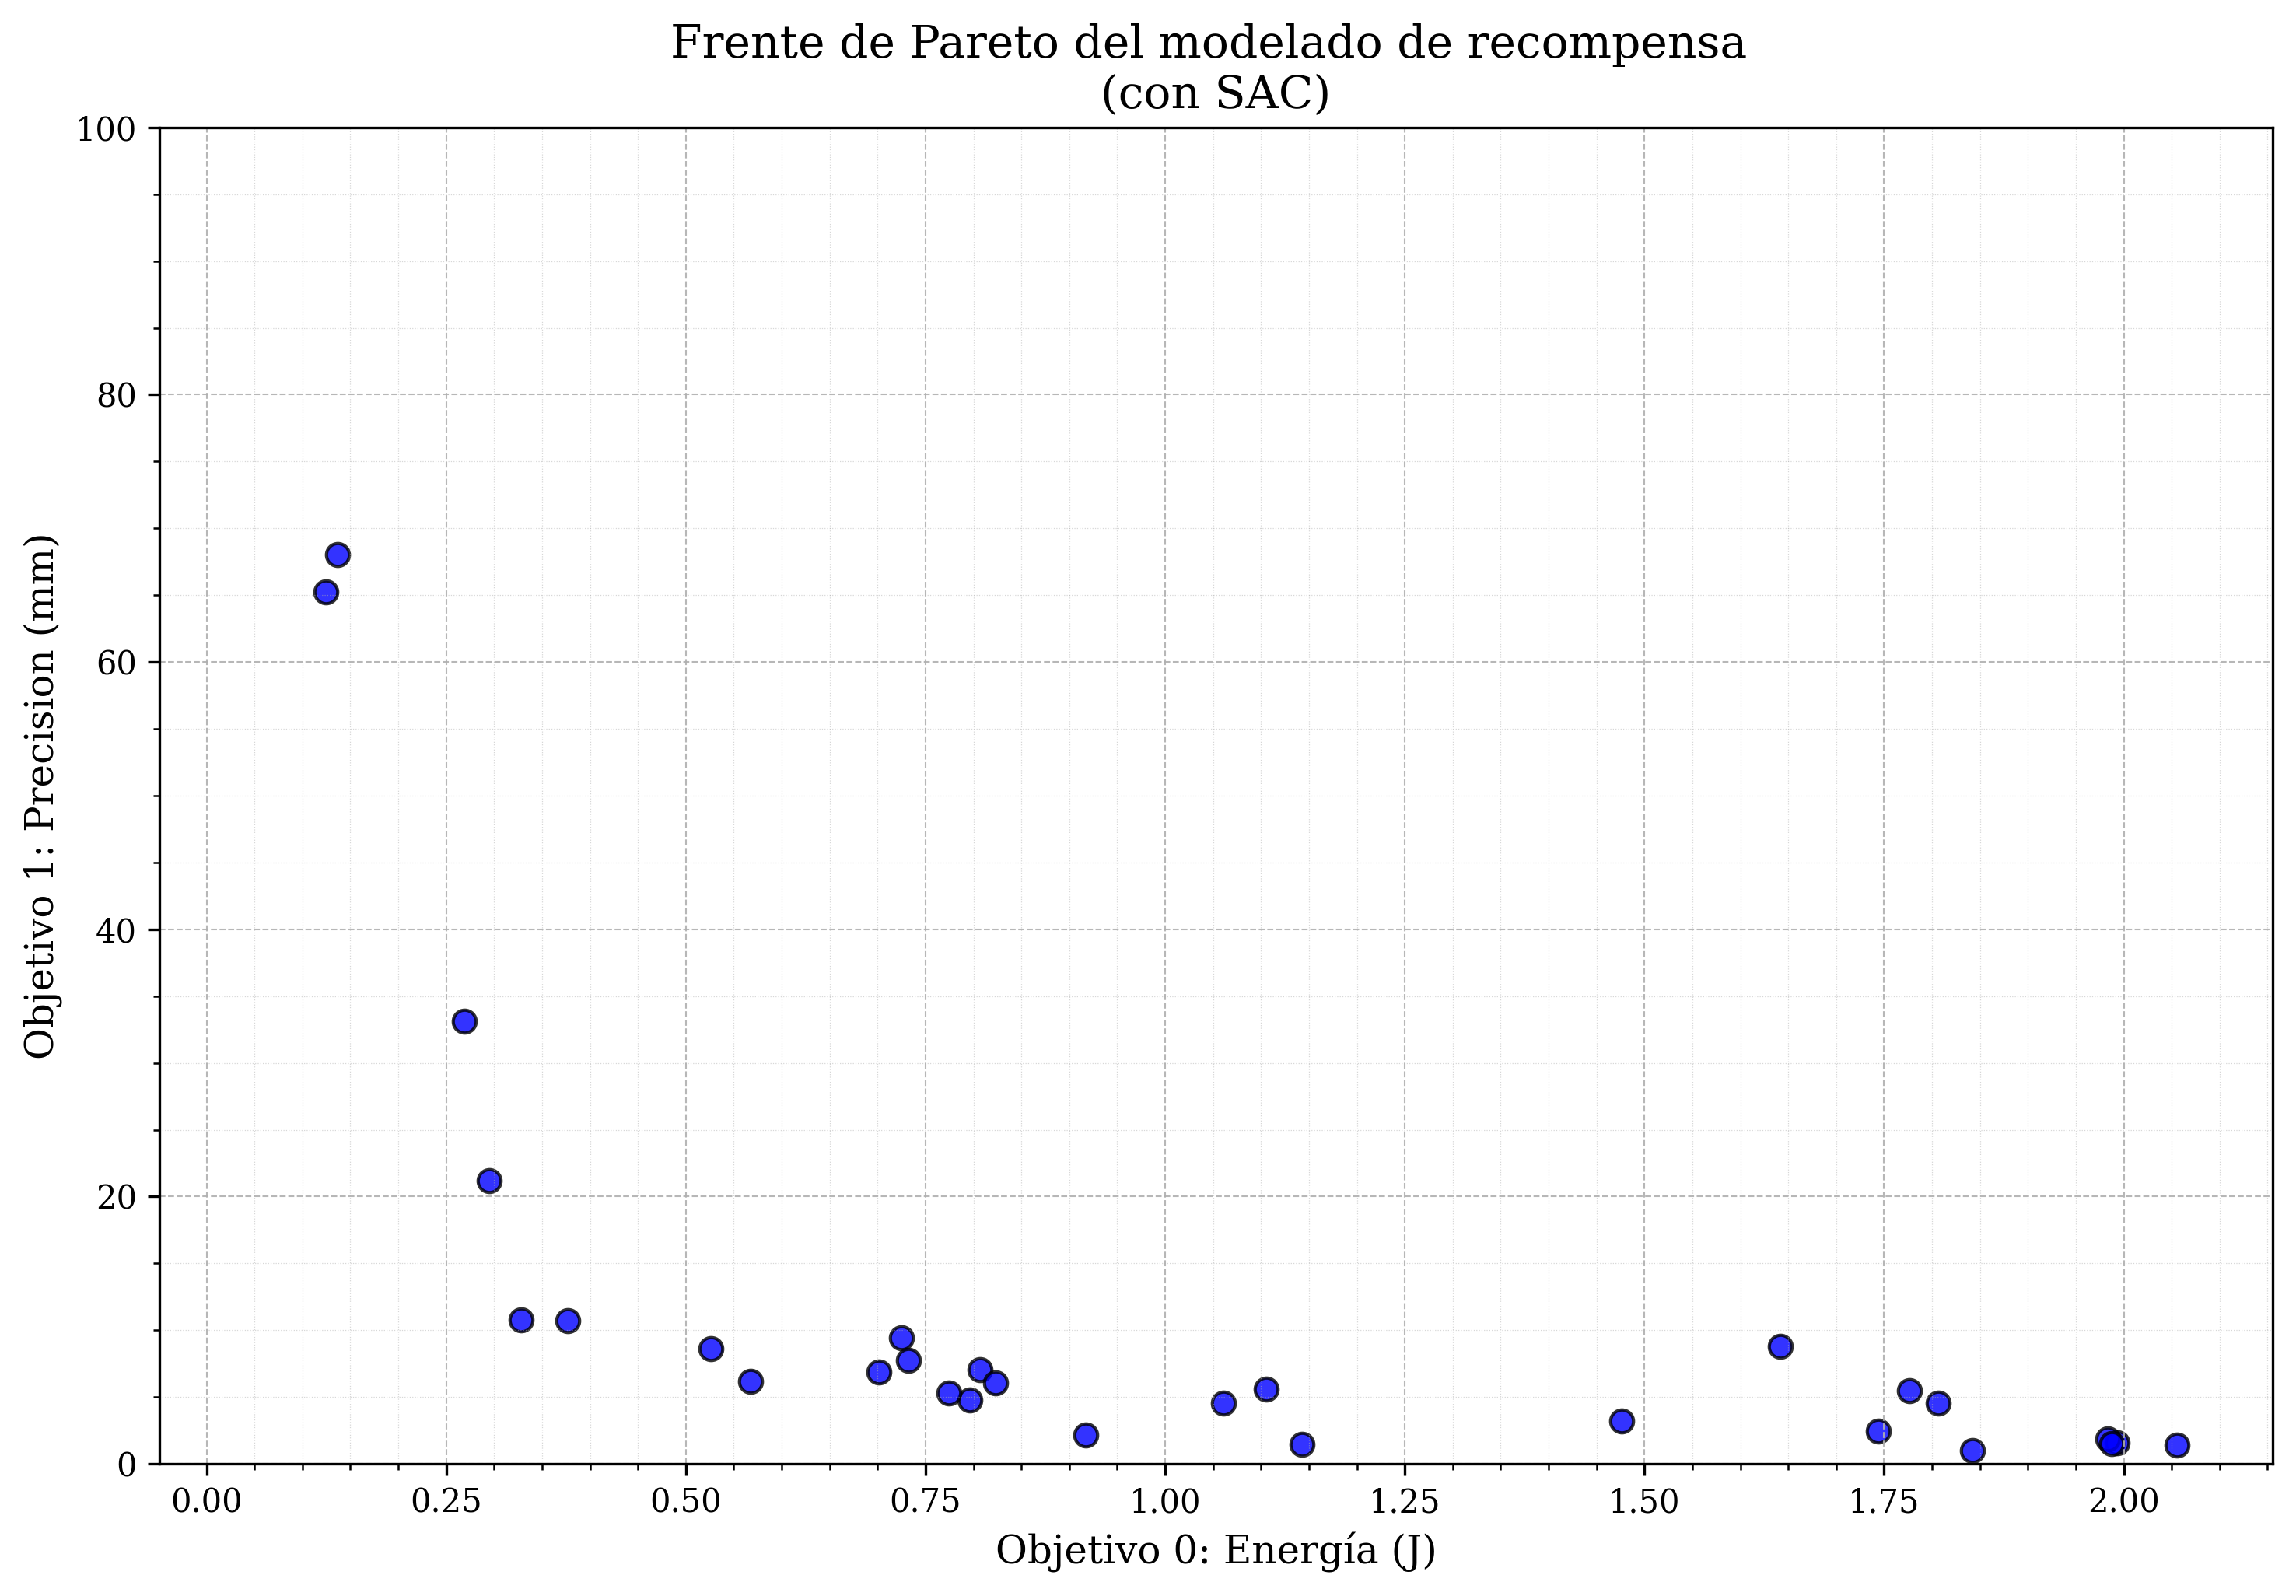

In [10]:
# === Get Completed Trials ===
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# Extract Objective values
energy_vals = np.array([t.values[0] for t in completed_trials])
precision_vals = np.array([t.values[1] for t in completed_trials]) * 1000  # Convert to mm

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot
ax.scatter(energy_vals, precision_vals, c='blue', s=50, edgecolors='k', alpha=0.8)

# Labels and title
ax.set_xlabel('Objetivo 0: Energía (J)')
ax.set_ylabel('Objetivo 1: Precision (mm)')
ax.set_title('Frente de Pareto del modelado de recompensa \n(con SAC)')

# Y-axis limit to max 100 mm
ax.set_ylim(0, 100)

# Grid with minor ticks
ax.minorticks_on()
ax.grid(which='major', linestyle='--', linewidth=0.5, alpha=0.9)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

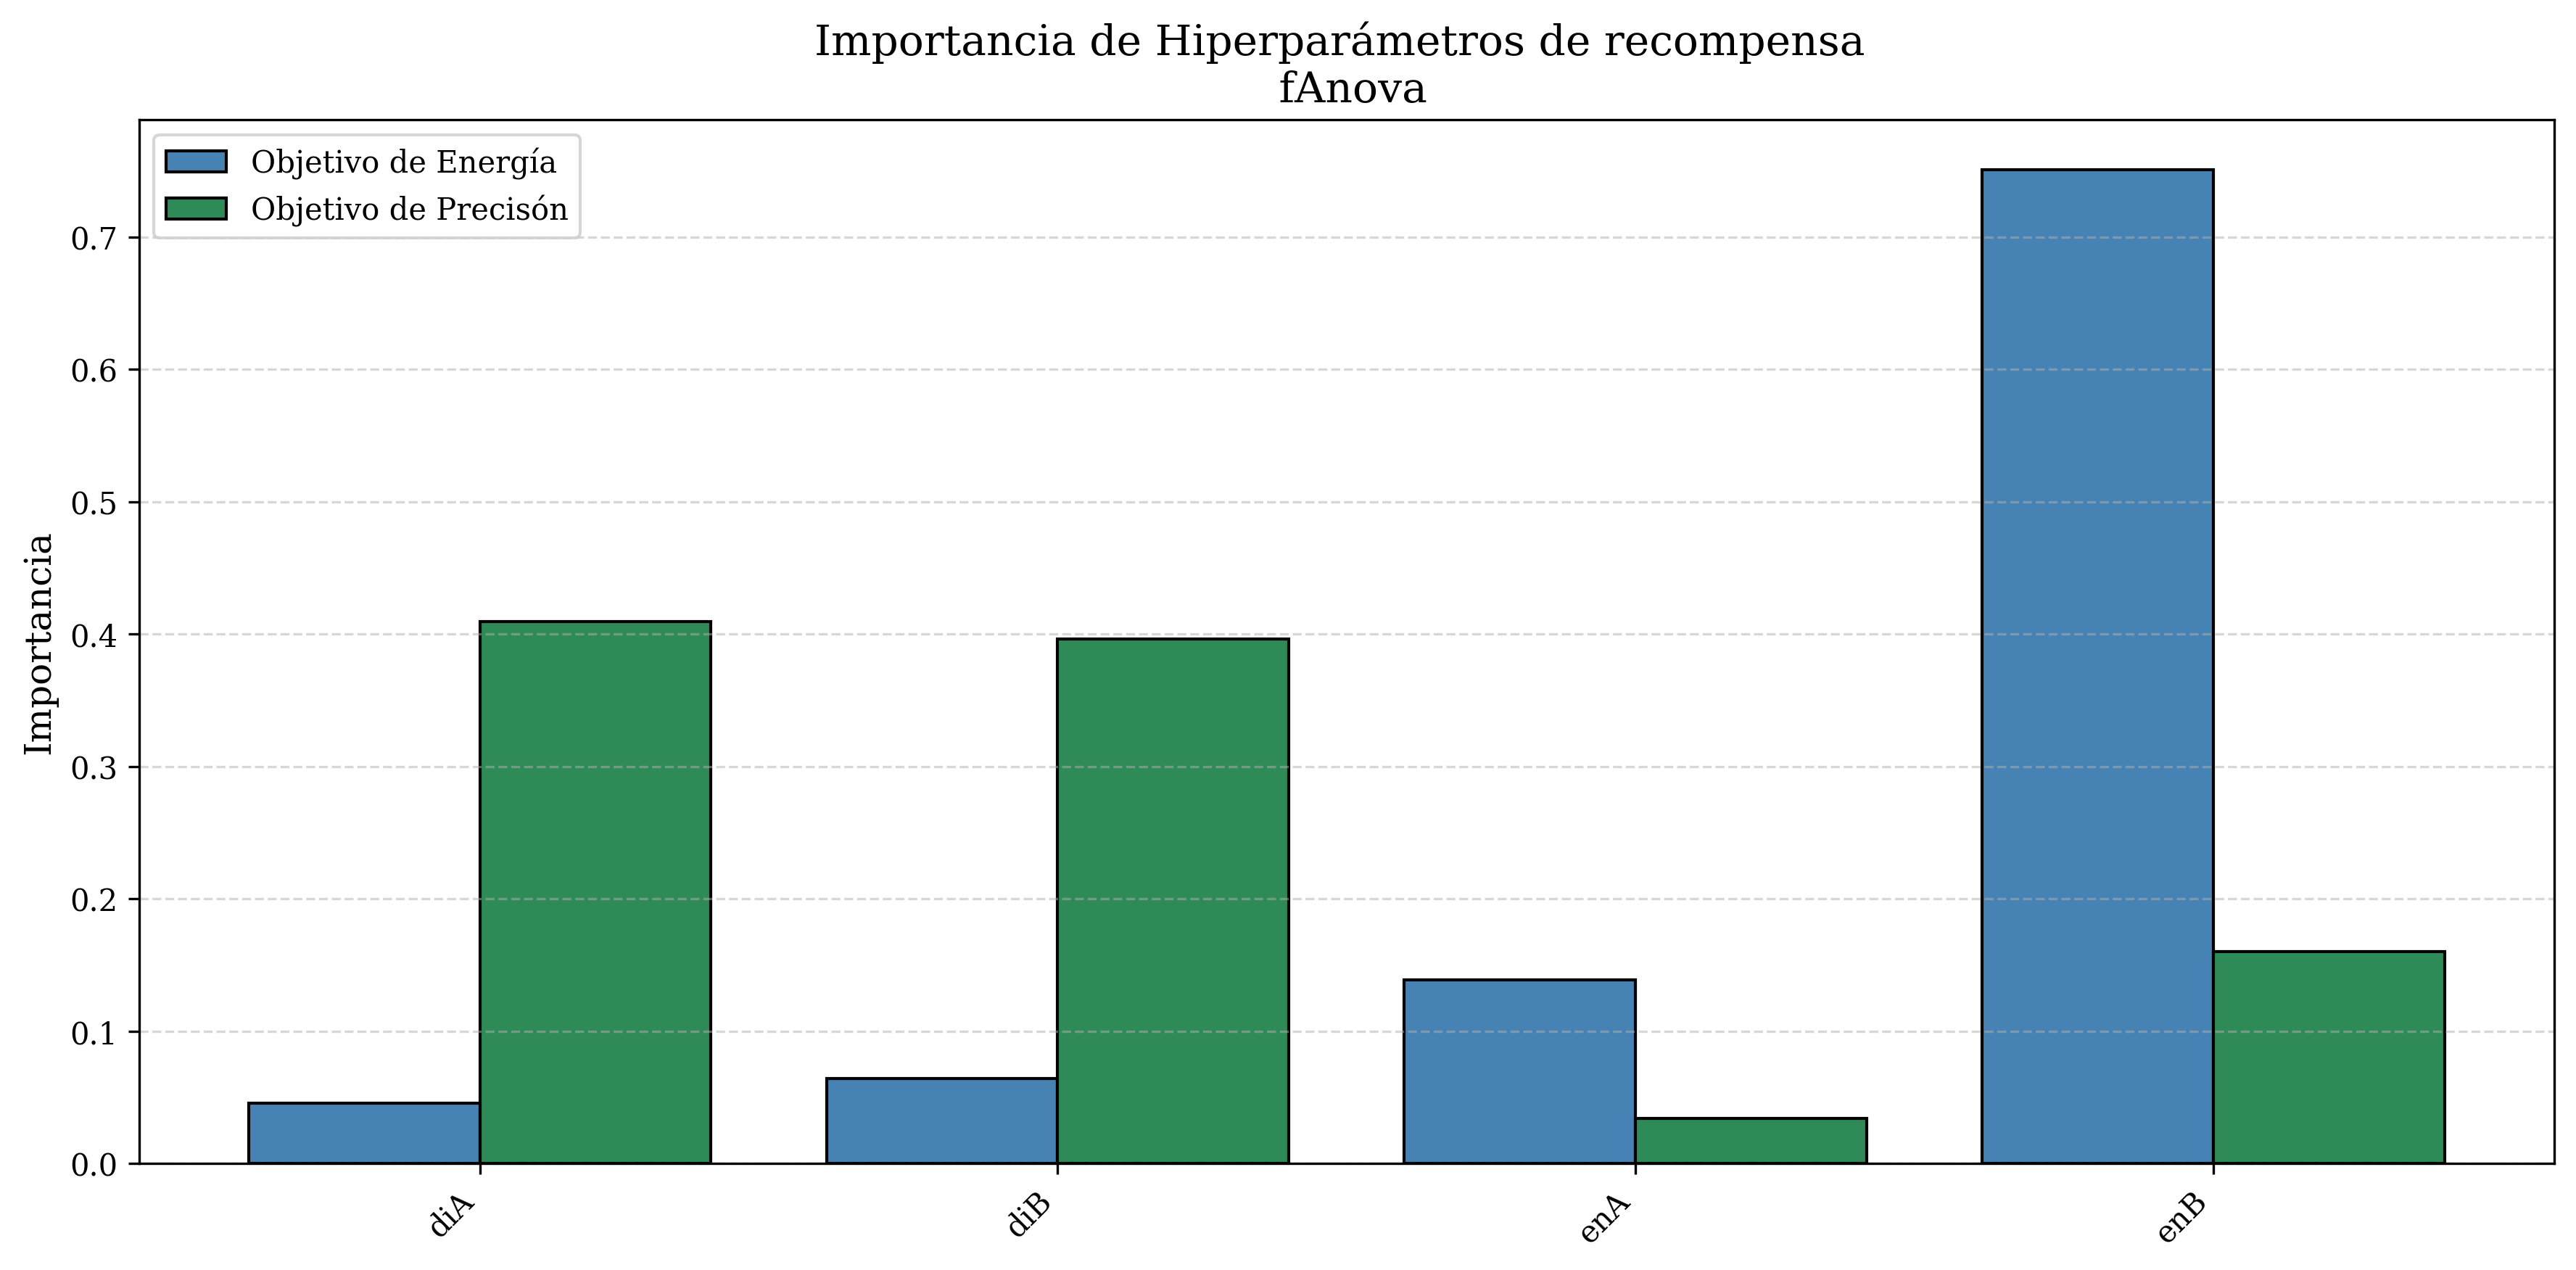

In [11]:
# === Importance Evaluator (fANOVA) ===
evaluator = optuna.importance.FanovaImportanceEvaluator()

# --- Importance for Energy (Objective 0) ---
importance_energy = optuna.importance.get_param_importances(study, target=lambda t: t.values[0], evaluator=evaluator)
df_energy = pd.Series(importance_energy)

# --- Importance for Precision (Objective 1) ---
importance_precision = optuna.importance.get_param_importances(study, target=lambda t: t.values[1], evaluator=evaluator)
df_precision = pd.Series(importance_precision)

# === Align Parameters ===
# Ensure both Series have same index order
all_params = sorted(set(df_energy.index).union(df_precision.index))

energy_vals = [df_energy.get(param, 0) for param in all_params]
precision_vals = [df_precision.get(param, 0) for param in all_params]

# === Grouped Bar Plot ===
x = np.arange(len(all_params))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

# Energy bars
ax.bar(x - bar_width/2, energy_vals, width=bar_width, color='steelblue', edgecolor='black', label='Objetivo de Energía')

# Precision bars
ax.bar(x + bar_width/2, precision_vals, width=bar_width, color='seagreen', edgecolor='black', label='Objetivo de Precisón')

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(all_params, rotation=45, ha='right')

# Labels & Title
ax.set_ylabel('Importancia')
ax.set_title('Importancia de Hiperparámetros de recompensa \n fAnova')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

# Legend
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
def load_rollout_rewards(logs_dir="logs", tag="rollout/ep_rew_mean"):
    logs_path = os.path.abspath(logs_dir)
    print(f"📂 Loading logs from: {logs_path}")

    all_data = {}

    for folder in os.listdir(logs_path):
        full_path = os.path.join(logs_path, folder)
        if os.path.isdir(full_path):
            try:
                reader = SummaryReader(full_path, pivot=False)
                df = reader.scalars
                df_tag = df[df["tag"] == tag].copy()
                if not df_tag.empty:
                    df_tag.reset_index(drop=True, inplace=True)
                    all_data[folder] = df_tag[["step", "value"]]
                else:
                    print(f"⚠️ Tag '{tag}' not found in {folder}")
            except Exception as e:
                print(f"❌ Error reading {folder}: {e}")

    if not all_data:
        print("❌ No valid data loaded.")
    return all_data

In [13]:
reward_data = load_rollout_rewards("logs")



📂 Loading logs from: c:\Users\juanp\Desktop\Master-Thesis\five_bar\RL\logs


In [14]:
def plot_separated_algorithms(reward_data, group1=("a2c", "ddpg"), smooth=False, window=10):
    group1 = tuple(group1)

    # Separate into groups
    group1_data = {k: v for k, v in reward_data.items() if k.lower().startswith(group1)}
    group2_data = {k: v for k, v in reward_data.items() if k not in group1_data}

    def clean_label(folder_name):
        return folder_name.split("_")[0].upper()  # e.g., 'sac_xyz...' -> 'SAC'

    # --- Plot Group 1 ---
    plt.figure(figsize=(12, 6))
    for label, df in group1_data.items():
        y_vals = df["value"]
        if smooth and len(y_vals) >= window:
            y_vals = y_vals.rolling(window=window).mean()
        plt.plot(df["step"], y_vals, label=clean_label(label))
    plt.xlabel("Paso")
    plt.ylabel("Recompensa media del episodio")
    plt.title("Curva de entrenamiento: A2C & DDPG")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

    # --- Plot Group 2 ---
    plt.figure(figsize=(12, 6))
    for label, df in group2_data.items():
        y_vals = df["value"]
        if smooth and len(y_vals) >= window:
            y_vals = y_vals.rolling(window=window).mean()
        plt.plot(df["step"], y_vals, label=clean_label(label))
    plt.xlabel("Paso")
    plt.ylabel("Recompensa media del episodio")
    plt.title("Curva de entrenamiento: PPO, SAC & TD3")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()


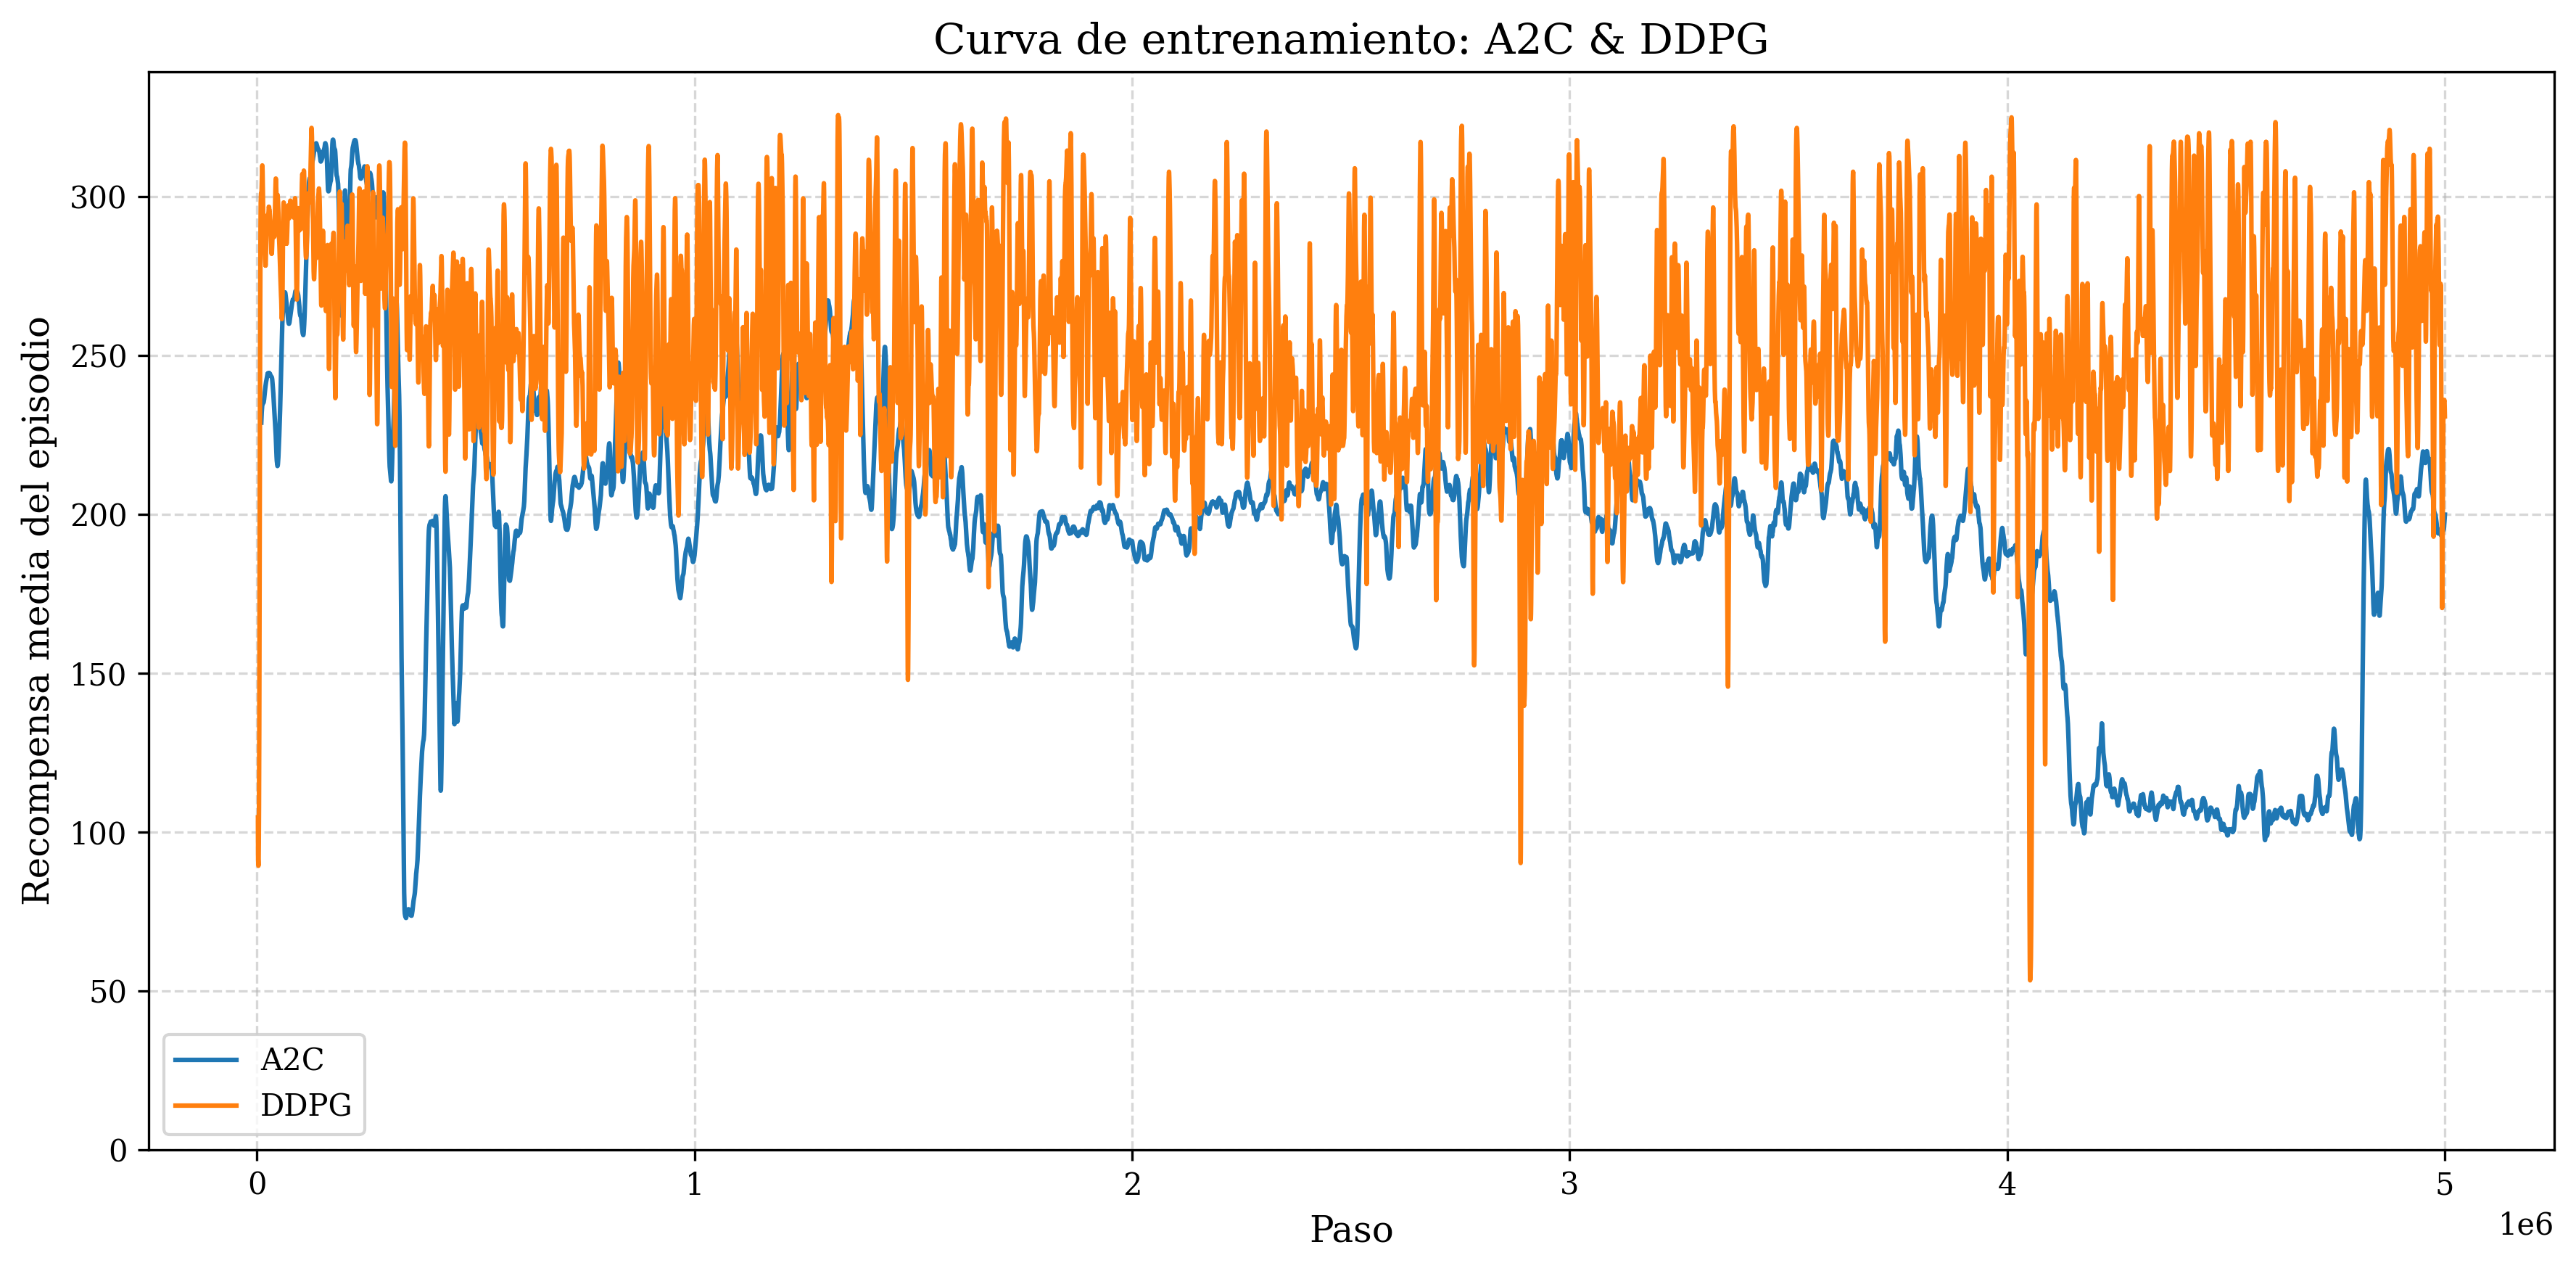

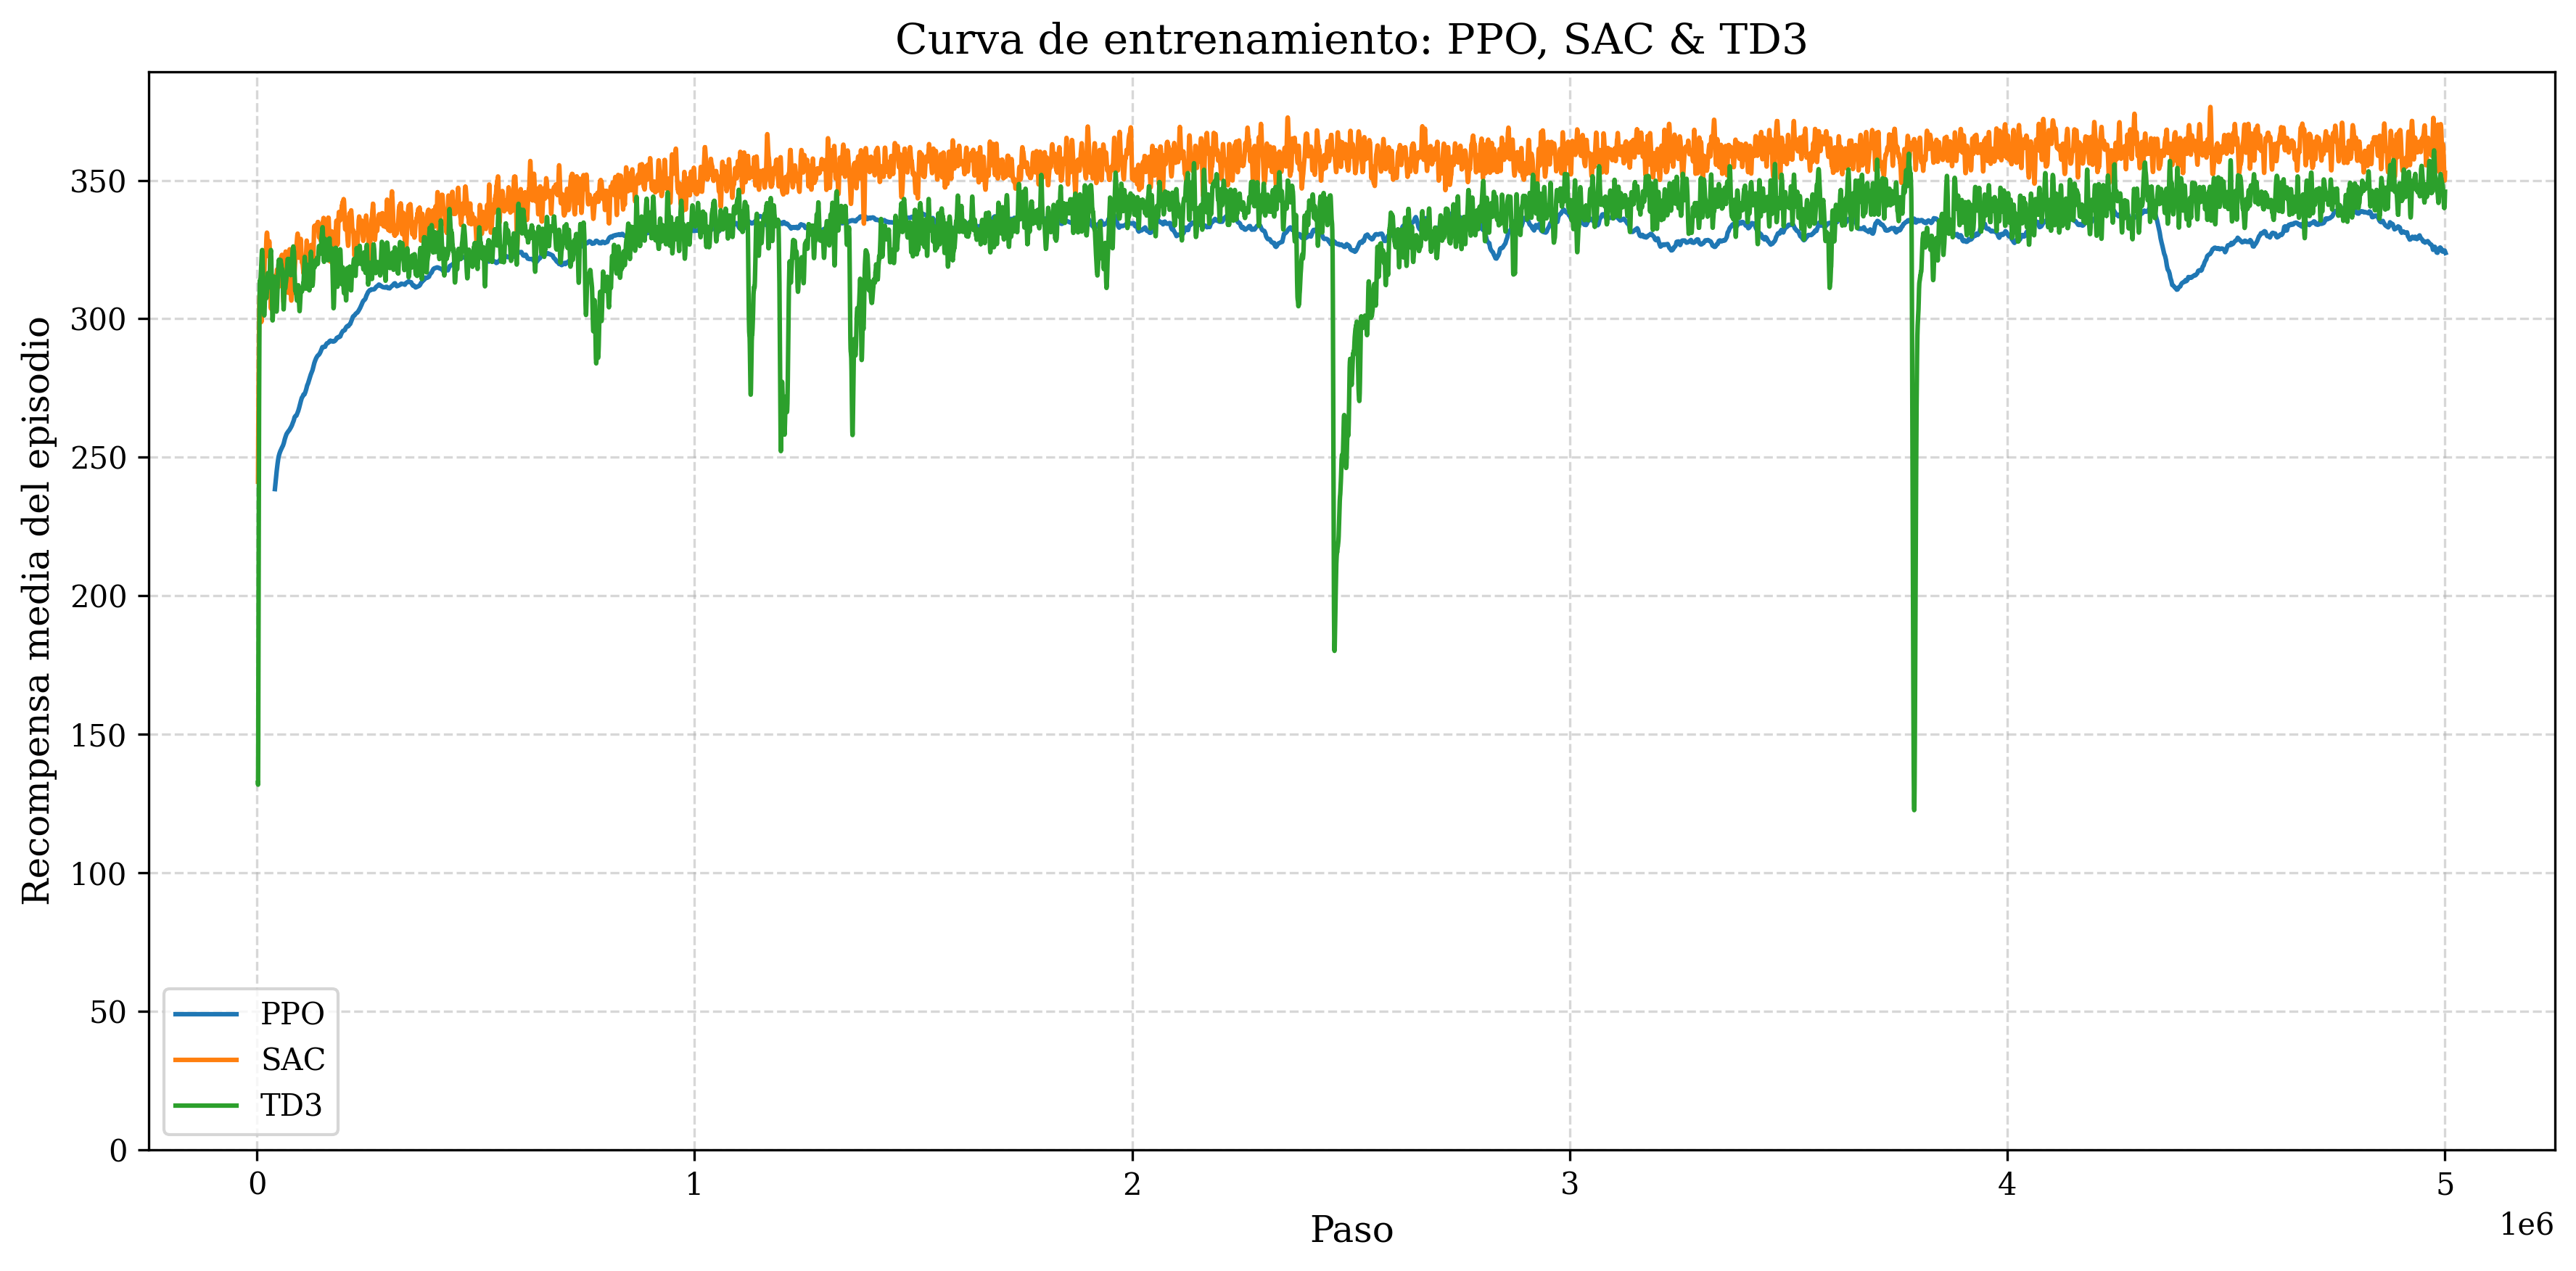

In [15]:
plot_separated_algorithms(reward_data, group1=("a2c", "ddpg"), smooth=True, window=20)


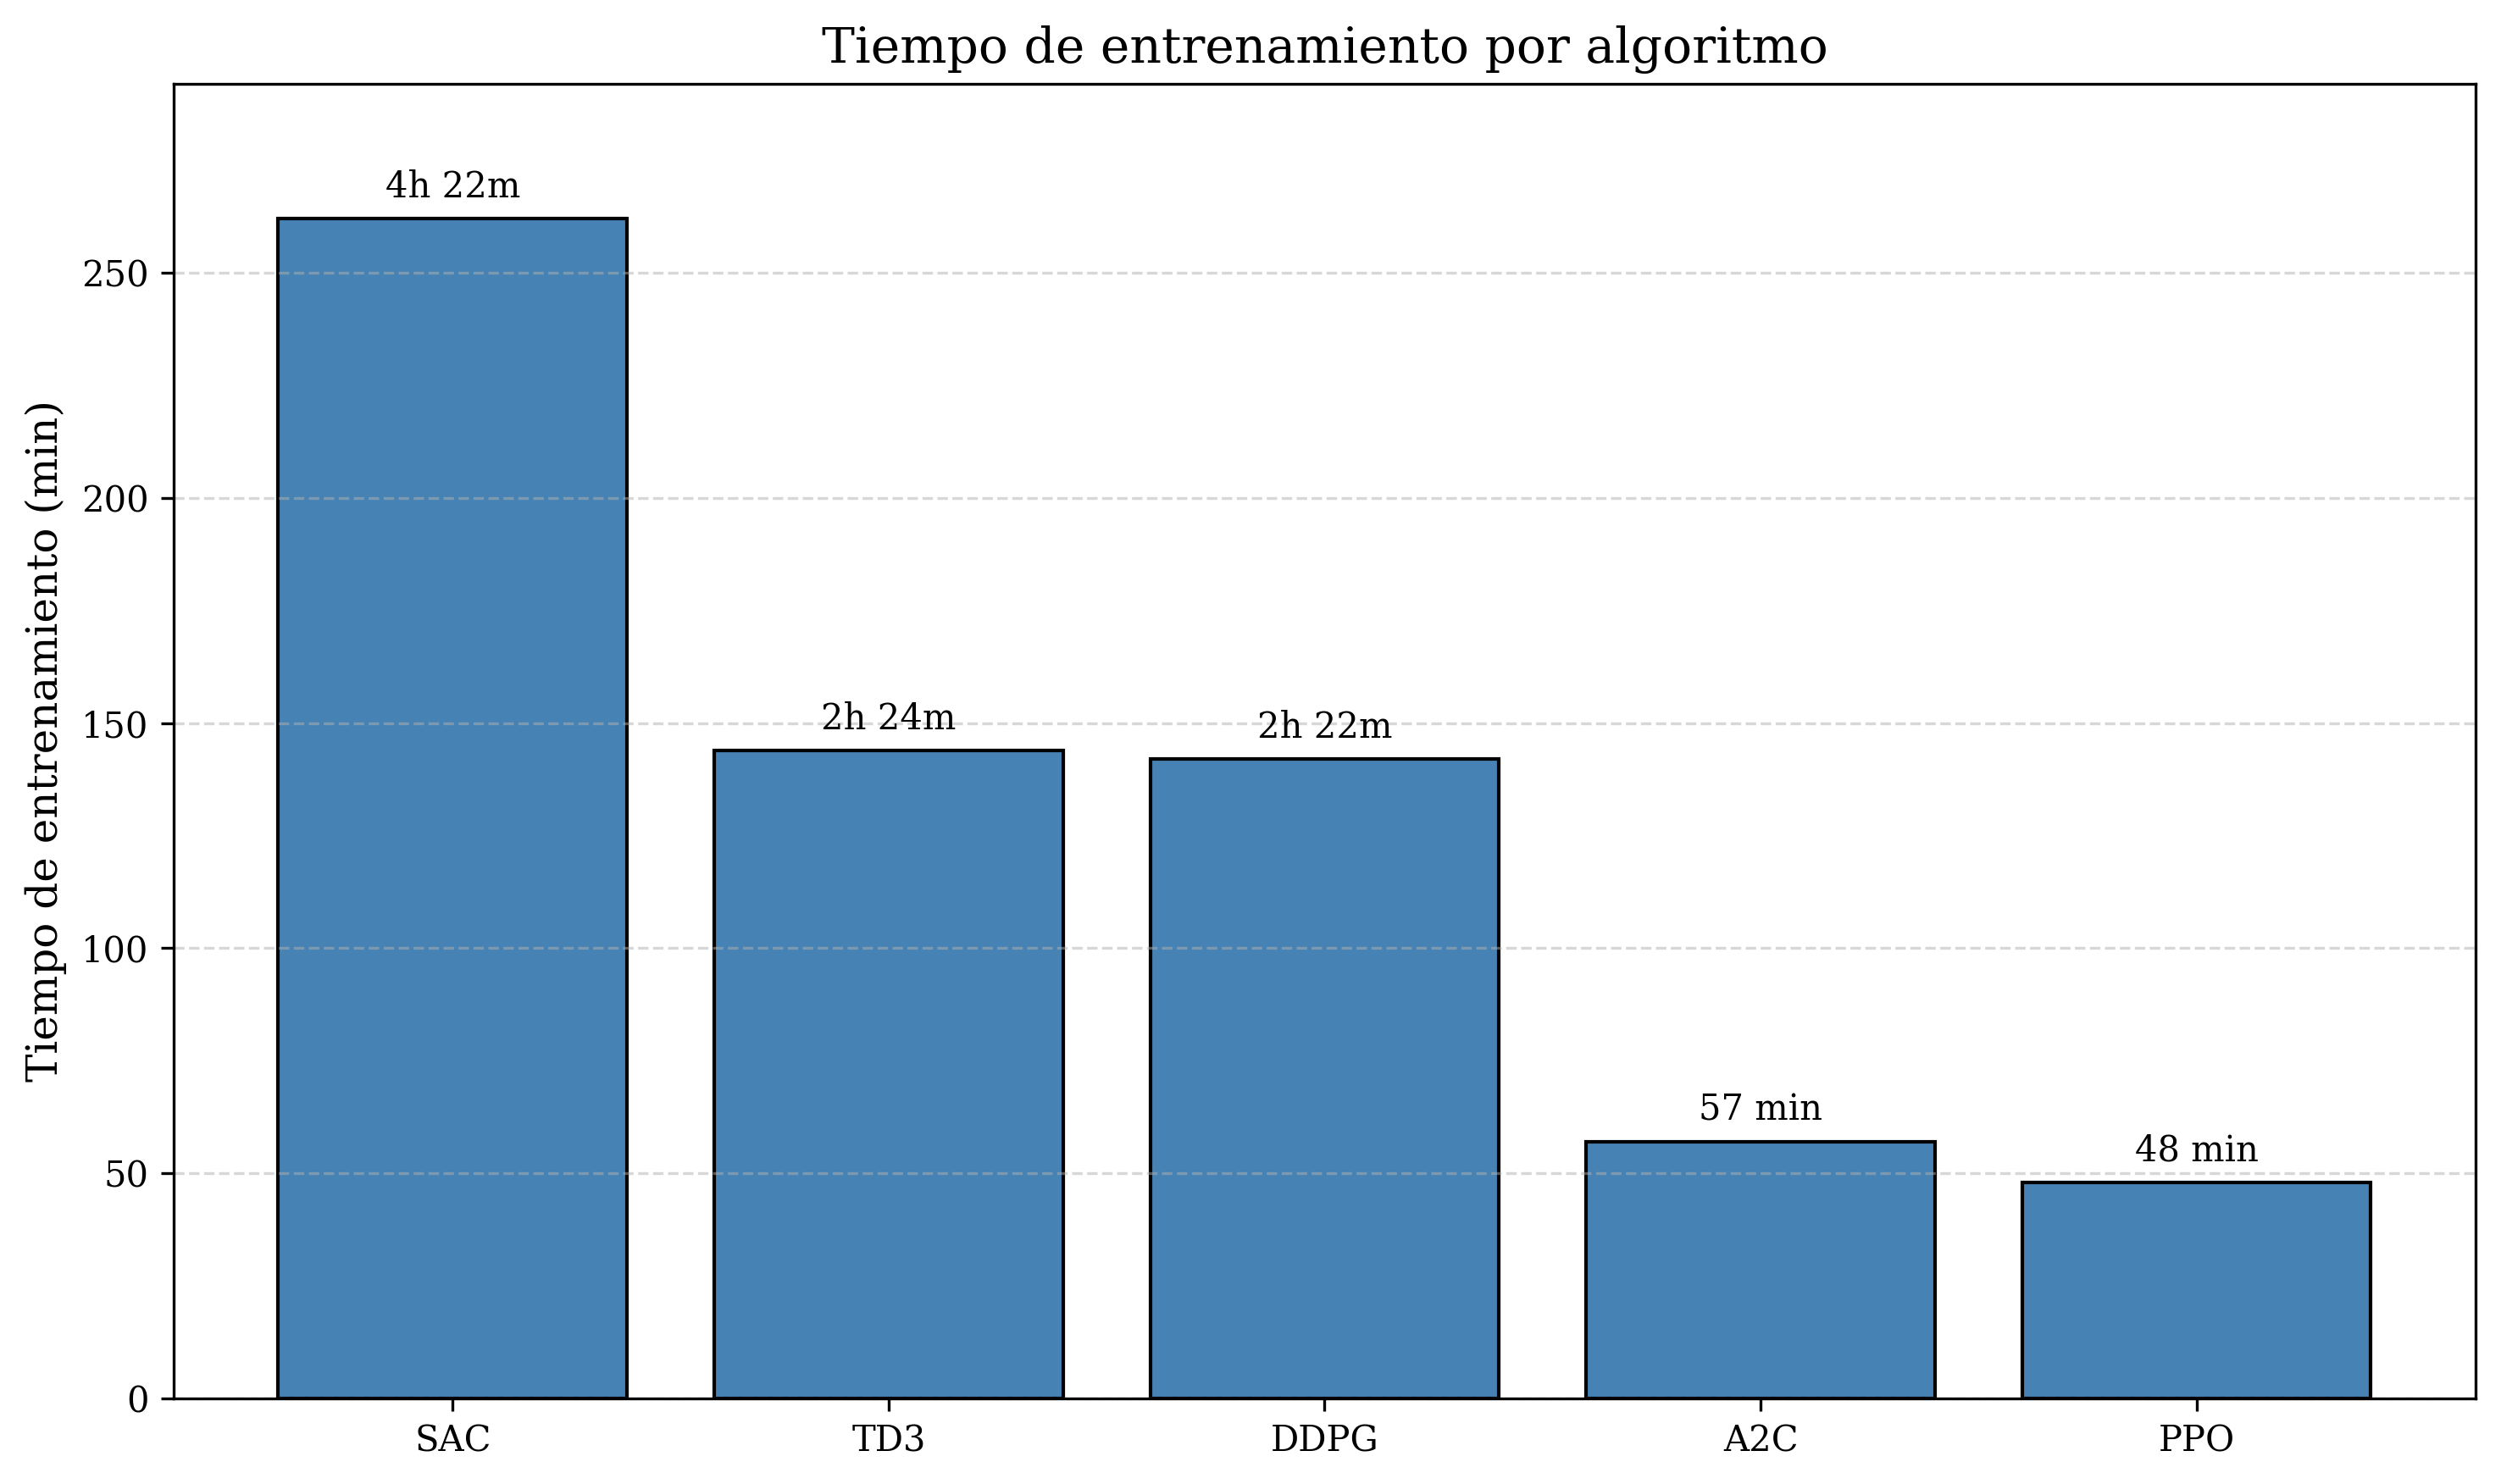

In [16]:
# Training times in minutes
times_minutes = {
    'DDPG': 2 * 60 + 22,
    'SAC':  4 * 60 + 22,
    'TD3':  2 * 60 + 24,
    'PPO':  48,
    'A2C':  57
}

# Sort by duration (optional)
algos_sorted, durations_sorted = zip(*sorted(times_minutes.items(), key=lambda x: x[1], reverse=True))

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(algos_sorted, durations_sorted, color='steelblue', edgecolor='black')

# Add labels above bars
for bar, minutes in zip(bars, durations_sorted):
    hours = minutes // 60
    mins = minutes % 60
    label = f"{hours}h {mins}m" if hours else f"{mins} min"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             label, ha='center', va='bottom', fontsize=10)

plt.ylabel("Tiempo de entrenamiento (min)")
plt.title("Tiempo de entrenamiento por algoritmo")
plt.ylim(0, max(durations_sorted) + 30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()